# HyperRAG V2 — Notebook 6: Chunking, FAISS & Retrieval Explained

This notebook is a **visual, step-by-step deep dive** into the retrieval engine mechanics.
Every concept is explained with working code and plots before moving to the next.

**Topics covered:**
1. **The problem** — why raw text search fails
2. **Chunking** — splitting large documents into indexable pieces
3. **Embeddings** — converting text into dense vectors that capture meaning
4. **Cosine similarity** — measuring semantic closeness between vectors
5. **FAISS** — fast similarity search across thousands of vectors
6. **The full retrieval pipeline** — end-to-end trace of one question
7. **HyperRAG graph expansion** — how hyperlinks bridge multi-hop gaps

**Prerequisite:** Run notebook 01 to create `data/corpus.json` and `data/questions.json`.


In [2]:
import json
import sys
from pathlib import Path
from collections import Counter

import faiss
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# ── Paths ─────────────────────────────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():
    BASE_DIR = Path('v2')
else:
    raise FileNotFoundError('Run from v2/ or from HyperRAG-M2/')

DATA_DIR = BASE_DIR / 'data/test_data'
sys.path.insert(0, str(BASE_DIR))
from utils import embed_texts, build_index, retrieve, get_model, compute_em, compute_f1, compute_supporting_recall

with open(DATA_DIR / 'corpus.json')    as f: corpus    = json.load(f)
with open(DATA_DIR / 'questions.json') as f: questions = json.load(f)

print(f'Corpus    : {len(corpus)} Wikipedia pages')
print(f'Questions : {len(questions)} HotpotQA questions')
print(f'Page keys : {list(corpus[0].keys())}')
print()
print(f'Total corpus size: {sum(len(p["text"]) for p in corpus):,} chars  '
      f'({sum(len(p["text"].split()) for p in corpus):,} words)')

Corpus    : 40 Wikipedia pages
Questions : 20 HotpotQA questions
Page keys : ['title', 'text', 'html', 'links']

Total corpus size: 246,697 chars  (42,224 words)


---
## Part 1 — The Problem: Finding Information in a Sea of Text

Our corpus contains 40 Wikipedia pages totalling ~100,000 words. For each user question,
we need to find the 5 most relevant pages in milliseconds.

**Why keyword search fails:**

```
Question: "What city is the head office of the Oberoi hotel chain?"
Answer  : "Delhi"   (the Wikipedia article says "New Delhi")
```

A keyword search for `"Delhi"` would miss the article because it says `"New Delhi"`.  
A search for `"head office"` would hit many pages with offices.  
**Semantic search** solves this by comparing *meaning*, not exact words.


In [3]:
q = questions[0]
print(f'Question  : {q["question"]}')
print(f'Gold answer: {q["answer"]}')
print(f'Gold pages : {q["supporting_titles"]}')
print()

# Show that keyword search is brittle
keyword = q['answer'].lower()   # 'delhi'
print(f'Keyword search for "{keyword}" in each page text:')
print(f'{"Match":>6}  {"Page"}')
print('-' * 55)
for p in corpus:
    hit = keyword in p['text'].lower()
    gold = '←GOLD' if p['title'] in q['supporting_titles'] else ''
    if hit or gold:
        print(f'  {"YES" if hit else "NO ":>4}   {p["title"][:50]}  {gold}')

print()
print('Problem: the keyword "delhi" might match many unrelated pages,')
print('and might miss pages that say "New Delhi" or "the Indian capital".')

Question  : The Oberoi family is part of a hotel company that has a head office in what city?
Gold answer: Delhi
Gold pages : ['The Oberoi Group', 'Oberoi family']

Keyword search for "delhi" in each page text:
 Match  Page
-------------------------------------------------------
   YES   India  
   YES   Oberoi family  ←GOLD
   YES   The Oberoi Group  ←GOLD

Problem: the keyword "delhi" might match many unrelated pages,
and might miss pages that say "New Delhi" or "the Indian capital".


---
## Part 2 — Chunking: Splitting Documents into Searchable Pieces

**Chunking** is the process of dividing a large document into smaller, overlapping segments.
Each chunk becomes one *searchable unit* in the index.

### Why chunk instead of indexing the whole page?
1. **Token limits** — embedding models accept at most 512 tokens (~380 words). A Wikipedia page has 500–2,000 words.
2. **Precision** — a page about *France* might mention Paris, Lyon, and Marseille. A chunk about Paris specifically is more relevant to a Paris question.
3. **Noise reduction** — irrelevant sentences pull the embedding away from the relevant part.

### Three common strategies

| Strategy | Split on | Pros | Cons |
|----------|----------|------|------|
| **Fixed-size** | Every N characters | Simple, predictable | Breaks mid-sentence |
| **Sentence-level** | Sentence boundaries | Clean boundaries | Variable length |
| **Page-level** *(our choice)* | One page = one chunk | Simple for whole-page reasoning | Loses intra-page precision |

> **In HyperRAG V2:** We use page-level chunking because HotpotQA requires reasoning over
> complete Wikipedia articles, and our corpus is small enough that whole-page embeddings work well.


In [4]:
sample_page = corpus[1]   # pick a page
text        = sample_page['text']
print(f'Page: "{sample_page["title"]}"  ({len(text)} chars, {len(text.split())} words)')
print()

# ── Strategy 1: Fixed-size chunking ───────────────────────────────────────────
def fixed_size_chunks(text: str, size: int = 300, overlap: int = 50) -> list[str]:
    """Split text into fixed-character-count windows with overlap."""
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start : start + size])
        start += size - overlap
    return chunks


# ── Strategy 2: Sentence-level chunking ───────────────────────────────────────
def sentence_chunks(text: str, group_size: int = 3) -> list[str]:
    """Group every N sentences into one chunk."""
    raw   = [s.strip() for s in text.replace('\n', ' ').split('.') if s.strip()]
    return ['. '.join(raw[i:i+group_size]) + '.' for i in range(0, len(raw), group_size)]


fixed = fixed_size_chunks(text, size=300, overlap=50)
sents = sentence_chunks(text, group_size=3)

print('Chunking strategy comparison:')
print(f'  Fixed-size  (300 chars, 50 overlap) : {len(fixed):>3} chunks')
print(f'  Sentence-level (3 sentences each)   : {len(sents):>3} chunks')
print(f'  Page-level (our approach)           :   1 chunk')
print()
print('--- Fixed-size chunk #1 (300 chars) ---')
print(fixed[0])
print()
print('--- Sentence chunk #1 ---')
print(sents[0])

Page: "Allie Goertz"  (3193 chars, 540 words)

Chunking strategy comparison:
  Fixed-size  (300 chars, 50 overlap) :  13 chunks
  Sentence-level (3 sentences each)   :  21 chunks
  Page-level (our approach)           :   1 chunk

--- Fixed-size chunk #1 (300 chars) ---
American comedian and singer-songwriter (born 1991) Musical artist Allison Beth Goertz (born March 2, 1991) is an American comedy musician , writer and former editor for Mad magazine. Goertz is known for her satirical songs based on various pop culture topics. Early life [ edit ] Goertz grew up in L

--- Sentence chunk #1 ---
American comedian and singer-songwriter (born 1991) Musical artist Allison Beth Goertz (born March 2, 1991) is an American comedy musician , writer and former editor for Mad magazine. Goertz is known for her satirical songs based on various pop culture topics. Early life [ edit ] Goertz grew up in Long Beach, California , the daughter of an elementary school teacher mother and a web graphic designer

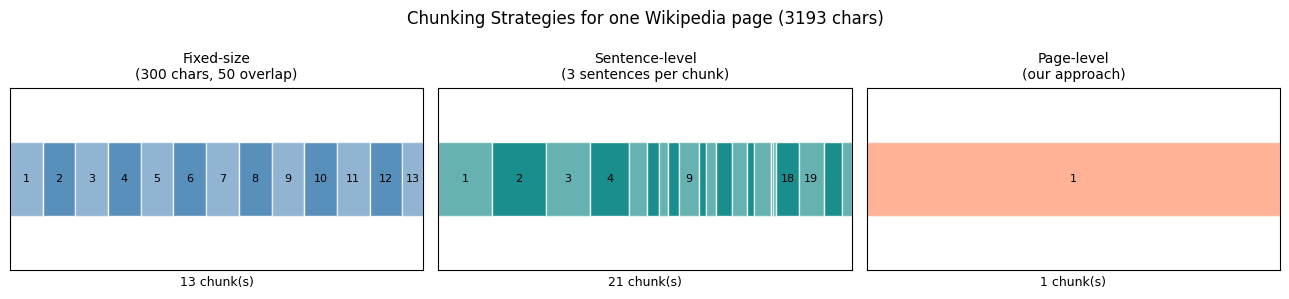

Each coloured block = one chunk. More chunks = more granular but more index entries.


In [5]:
# ── Visualize how the page gets split under each strategy ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
fig.suptitle(f'Chunking Strategies for one Wikipedia page ({len(text)} chars)', fontsize=12)

def draw_chunks(ax, chunks, title, color):
    total = max(sum(len(c) for c in chunks), 1)
    left  = 0
    for i, c in enumerate(chunks):
        w = len(c) / total
        ax.barh(0, w, left=left, color=color, alpha=0.6 + (i % 2) * 0.3, height=0.4,
                edgecolor='white', linewidth=1)
        if w > 0.05:
            ax.text(left + w / 2, 0, str(i+1), ha='center', va='center', fontsize=8)
        left += w
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f'{len(chunks)} chunk(s)', fontsize=9)

draw_chunks(axes[0], fixed, 'Fixed-size\n(300 chars, 50 overlap)', 'steelblue')
draw_chunks(axes[1], sents, 'Sentence-level\n(3 sentences per chunk)', 'teal')
draw_chunks(axes[2], [text], 'Page-level\n(our approach)', 'coral')

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'chunking_strategies.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Each coloured block = one chunk. More chunks = more granular but more index entries.')

---
## Part 3 — Embeddings: Text as Points in Geometric Space

An **embedding** is a list of numbers (a vector) that encodes the *meaning* of a text.
Text with similar meanings produces vectors that point in similar directions.

**Our model:** `sentence-transformers/all-MiniLM-L6-v2`
- Architecture: 6-layer transformer with mean-pooling
- Output: **384-dimensional** float32 vector
- Training: 1.17 billion sentence pairs (semantic similarity pairs)
- Speed: ~14,000 sentences/second on CPU

**Intuition:** The model has learned that "Paris" and "capital of France" should produce
nearby vectors, while "Paris" and "Mount Everest" should produce distant vectors.


In [6]:
# Load the model (cached after first call)
model = get_model()

example_texts = [
    'Paris is the capital of France.',           # text A
    "France's capital and largest city is Paris.",  # A paraphrase → should be very close
    'Berlin is the capital of Germany.',          # related domain, different city
    'Mount Everest is the highest mountain on Earth.',  # unrelated → should be far
    'The hotel has its head office in New Delhi, India.',   # from our HotpotQA context
]

vecs = embed_texts(example_texts)
print(f'Embedding matrix shape: {vecs.shape}  ({len(example_texts)} texts × 384 dims)')
print(f'Vector dtype          : {vecs.dtype}')
print(f'L2 norms (all should be ~1.0 after normalisation):')
print(f'  {np.round(np.linalg.norm(vecs, axis=1), 6)}')
print()
print(f'First 8 dimensions of text A: {np.round(vecs[0, :8], 4)}')
print(f'(The remaining 376 dimensions are not shown — each carries part of the meaning)')

Loading model: sentence-transformers/all-MiniLM-L6-v2 ...
Model loaded.
Embedding matrix shape: (5, 384)  (5 texts × 384 dims)
Vector dtype          : float32
L2 norms (all should be ~1.0 after normalisation):
  [1. 1. 1. 1. 1.]

First 8 dimensions of text A: [ 0.1007  0.0372  0.0282 -0.0417  0.0672 -0.0477  0.0094 -0.0108]
(The remaining 376 dimensions are not shown — each carries part of the meaning)


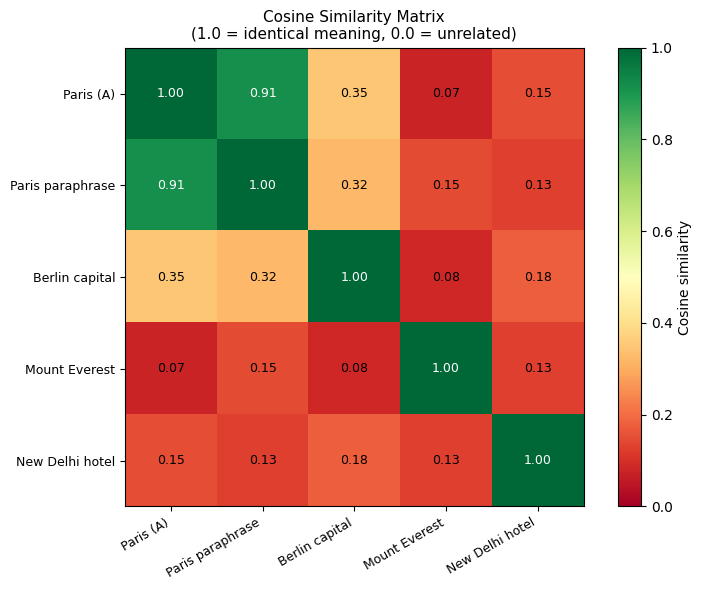

Key observations:
  Paris (A) vs Paraphrase      : 0.914  (very high — same meaning)
  Paris (A) vs Berlin capital  : 0.348  (moderate — same domain)
  Paris (A) vs Mount Everest   : 0.075  (low — unrelated topic)
  Paris (A) vs New Delhi hotel : 0.151  (low-moderate — different city)


In [7]:
# ── Cosine similarity matrix ───────────────────────────────────────────────────
sim_matrix = vecs @ vecs.T   # inner product = cosine sim after L2 norm

labels_short = [
    'Paris (A)',
    'Paris paraphrase',
    'Berlin capital',
    'Mount Everest',
    'New Delhi hotel',
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(labels_short)))
ax.set_yticks(range(len(labels_short)))
ax.set_xticklabels(labels_short, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(labels_short, fontsize=9)

for i in range(len(labels_short)):
    for j in range(len(labels_short)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black' if sim_matrix[i,j] < 0.85 else 'white')

plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('Cosine Similarity Matrix\n(1.0 = identical meaning, 0.0 = unrelated)', fontsize=11)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'sim_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

print('Key observations:')
print(f'  Paris (A) vs Paraphrase      : {sim_matrix[0,1]:.3f}  (very high — same meaning)')
print(f'  Paris (A) vs Berlin capital  : {sim_matrix[0,2]:.3f}  (moderate — same domain)')
print(f'  Paris (A) vs Mount Everest   : {sim_matrix[0,3]:.3f}  (low — unrelated topic)')
print(f'  Paris (A) vs New Delhi hotel : {sim_matrix[0,4]:.3f}  (low-moderate — different city)')

---
## Part 4 — The Math: Cosine Similarity and L2 Normalisation

### Cosine similarity formula

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{|\mathbf{a}| \cdot |\mathbf{b}|}$$

- $\mathbf{a} \cdot \mathbf{b}$ = dot product (sum of element-wise products)
- $|\mathbf{a}|$ = L2 norm (Euclidean length) = $\sqrt{a_1^2 + a_2^2 + \ldots + a_n^2}$
- $\cos(\theta) = 1.0$ → identical direction (same meaning)
- $\cos(\theta) = 0.0$ → perpendicular (unrelated meaning)

### The L2-normalisation trick

If we pre-normalise both vectors to have unit length ($|\mathbf{a}| = |\mathbf{b}| = 1$),
the formula simplifies to just the dot product:

$$\cos(\theta) = \mathbf{a}_{\text{norm}} \cdot \mathbf{b}_{\text{norm}}$$

**Why this matters:** FAISS's `IndexFlatIP` computes **inner products** (dot products) very fast.
By pre-normalising all vectors, we turn it into a cosine similarity engine — no extra computation needed.


In [8]:
# ── Step-by-step cosine similarity in 2D (easy to visualise) ─────────────────
a = np.array([3.0, 4.0])
b = np.array([1.0, 1.0])

dot_raw   = np.dot(a, b)
norm_a    = np.linalg.norm(a)
norm_b    = np.linalg.norm(b)
cos_sim   = dot_raw / (norm_a * norm_b)

a_norm = a / norm_a
b_norm = b / norm_b
dot_normalised = np.dot(a_norm, b_norm)

print('=== 2D Example ===')
print(f'a = {a}        b = {b}')
print(f'|a| = {norm_a:.3f}    |b| = {norm_b:.3f}')
print(f'dot(a, b)                  = {dot_raw:.3f}')
print(f'cos(a, b) = dot / (|a||b|) = {cos_sim:.4f}')
print()
print('After L2 normalisation:')
print(f'a_norm = {np.round(a_norm, 4)}  (|a_norm| = {np.linalg.norm(a_norm):.6f})')
print(f'b_norm = {np.round(b_norm, 4)}  (|b_norm| = {np.linalg.norm(b_norm):.6f})')
print(f'dot(a_norm, b_norm) = {dot_normalised:.4f}  ← equals cosine sim above')
print()
print('=== FAISS Connection ===')
print('We call faiss.normalize_L2(embeddings) before index.add().')
print('Then index.search() computes inner products == cosine similarities.')

=== 2D Example ===
a = [3. 4.]        b = [1. 1.]
|a| = 5.000    |b| = 1.414
dot(a, b)                  = 7.000
cos(a, b) = dot / (|a||b|) = 0.9899

After L2 normalisation:
a_norm = [0.6 0.8]  (|a_norm| = 1.000000)
b_norm = [0.7071 0.7071]  (|b_norm| = 1.000000)
dot(a_norm, b_norm) = 0.9899  ← equals cosine sim above

=== FAISS Connection ===
We call faiss.normalize_L2(embeddings) before index.add().
Then index.search() computes inner products == cosine similarities.


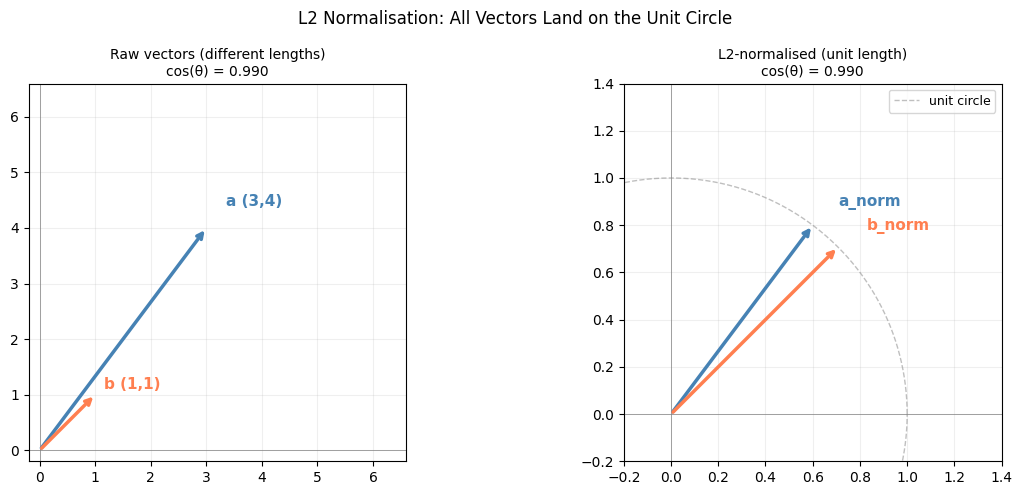

Key insight: after normalisation, the ANGLE between vectors equals their similarity.
FAISS measures this angle via a fast inner product.


In [9]:
# ── Visualise the vectors in 2D ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, pairs in [
    (axes[0], 'Raw vectors (different lengths)', [(a, 'a (3,4)', 'steelblue'), (b, 'b (1,1)', 'coral')]),
    (axes[1], 'L2-normalised (unit length)',    [(a_norm, 'a_norm', 'steelblue'), (b_norm, 'b_norm', 'coral')]),
]:
    max_val = max(np.linalg.norm(v) for v, _, _ in pairs) * 1.3 + 0.1
    for vec, label, color in pairs:
        ax.annotate('', xy=vec, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(vec[0] * 1.1 + 0.05, vec[1] * 1.1, label, color=color, fontsize=11, fontweight='bold')
    # Unit circle on right plot only
    if 'normalised' in title:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(np.cos(theta), np.sin(theta), '--', color='gray', lw=1, alpha=0.5, label='unit circle')
        ax.legend(fontsize=9)
    ax.set_xlim(-0.2, max_val)
    ax.set_ylim(-0.2, max_val)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.grid(True, alpha=0.2)
    ax.set_title(f'{title}\ncos(θ) = {cos_sim:.3f}', fontsize=10)

fig.suptitle('L2 Normalisation: All Vectors Land on the Unit Circle', fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'cosine_explained.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Key insight: after normalisation, the ANGLE between vectors equals their similarity.')
print('FAISS measures this angle via a fast inner product.')

---
## Part 5 — FAISS: Fast Similarity Search

**FAISS** (Facebook AI Similarity Search) is a library for searching large vector databases.
It stores all embedded chunks and finds the most similar ones to a query vector.

### `IndexFlatIP` — what we use
- **Flat** = stores all vectors verbatim (no compression)
- **IP** = Inner Product (dot product after L2 normalisation = cosine similarity)
- **Exact** = checks every stored vector — guaranteed top-k results
- **Good for:** corpora up to ~1 million vectors

### How `.search(q_vec, k)` works internally

```
for each stored vector v in index:
    score[v] = dot(q_vec, v)      # one multiply-and-add per dimension
return top-k indices with highest score
```

**Time complexity:** O(n × d) per query  
For our corpus: 40 pages × 384 dims = **15,360 operations** — microseconds on modern hardware.


In [10]:
print('=== Building a FAISS IndexFlatIP: Step by Step ===')
print()

# ── Step A: Embed all corpus pages ─────────────────────────────────────────────
print('Step A: Embed every page text into a 384-dim vector')
texts      = [p['text'] for p in corpus]
embeddings = embed_texts(texts)   # shape: (40, 384), already L2-normalised
print(f'  Shape: {embeddings.shape}   dtype: {embeddings.dtype}')
print(f'  L2 norms: min={np.linalg.norm(embeddings, axis=1).min():.6f}  '
      f'max={np.linalg.norm(embeddings, axis=1).max():.6f}  (all ≈ 1.0)')
print()

# ── Step B: Create the index ───────────────────────────────────────────────────
print('Step B: Create IndexFlatIP(384)')
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)     # empty index, dim=384
print(f'  Index type     : {type(index).__name__}')
print(f'  Dimension      : {dim}')
print(f'  Vectors stored : {index.ntotal}  (empty)')
print()

# ── Step C: Add vectors ────────────────────────────────────────────────────────
print('Step C: Add all corpus embeddings to the index')
index.add(embeddings)
print(f'  Vectors stored : {index.ntotal}  (one per page)')
print(f'  Memory used    : ~{index.ntotal * dim * 4 / 1024:.1f} KB  (40 × 384 × 4 bytes)')
print()

# ── Step D: Search ─────────────────────────────────────────────────────────────
print('Step D: Search for a query (k=5 nearest neighbours)')
q       = questions[0]
q_vec   = embed_texts([q['question']])   # shape: (1, 384)
print(f'  Query  : "{q["question"][:60]}"')
print(f'  q_vec shape: {q_vec.shape}  norm: {np.linalg.norm(q_vec[0]):.6f}')

scores, indices = index.search(q_vec, k=5)
print(f'  scores  shape : {scores.shape}   values : {np.round(scores[0], 4)}')
print(f'  indices shape : {indices.shape}  values : {indices[0]}')
print()

print('Mapping indices to page titles:')
print(f'{"Rank":<5} {"Score":>7}  {"Title"}')
print('-' * 55)
for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
    gold = '✓' if corpus[idx]['title'] in q['supporting_titles'] else ' '
    print(f'{rank:<5} {score:>7.4f}  {gold} {corpus[idx]["title"]}')

=== Building a FAISS IndexFlatIP: Step by Step ===

Step A: Embed every page text into a 384-dim vector


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

  Shape: (40, 384)   dtype: float32
  L2 norms: min=1.000000  max=1.000000  (all ≈ 1.0)

Step B: Create IndexFlatIP(384)
  Index type     : IndexFlatIP
  Dimension      : 384
  Vectors stored : 0  (empty)

Step C: Add all corpus embeddings to the index
  Vectors stored : 40  (one per page)
  Memory used    : ~60.0 KB  (40 × 384 × 4 bytes)

Step D: Search for a query (k=5 nearest neighbours)
  Query  : "The Oberoi family is part of a hotel company that has a head"
  q_vec shape: (1, 384)  norm: 1.000000
  scores  shape : (1, 5)   values : [0.6507 0.6507 0.197  0.1356 0.1297]
  indices shape : (1, 5)  values : [36 30 23 20 16]

Mapping indices to page titles:
Rank    Score  Title
-------------------------------------------------------
1      0.6507  ✓ The Oberoi Group
2      0.6507  ✓ Oberoi family
3      0.1970    Longs Drugs
4      0.1356    Indogrammodes
5      0.1297    House of Anubis


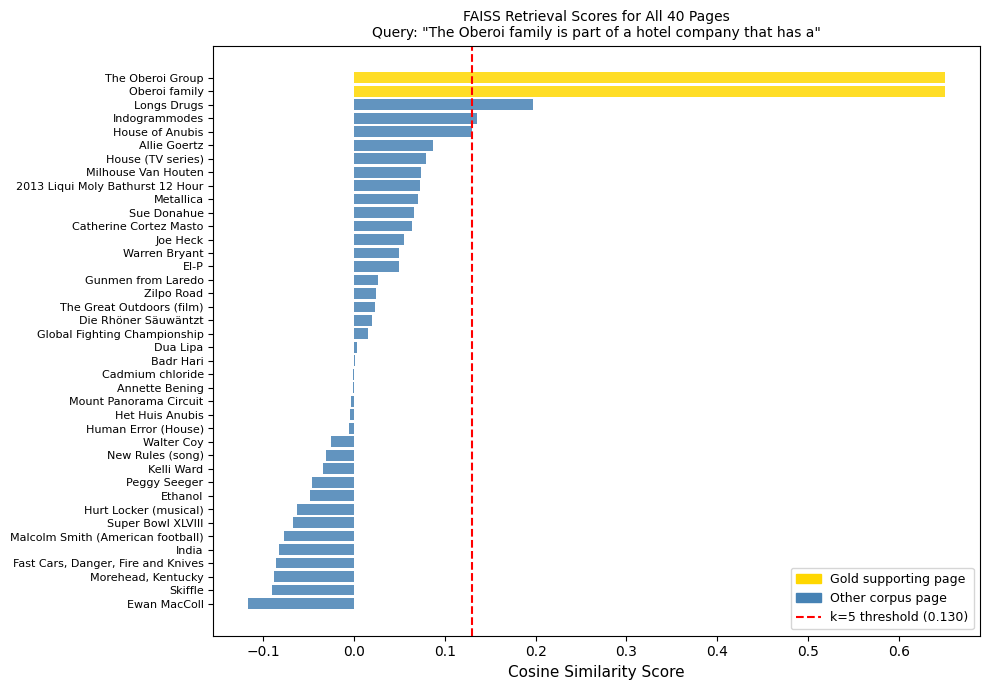

Pages to the right of the red line are retrieved (k=5).
Gold pages (in gold) should ideally be to the right.


In [11]:
# ── Visualise cosine scores for every page in the corpus ─────────────────────
q     = questions[0]
q_vec = embed_texts([q['question']])

# Search for ALL pages
scores_all, idxs_all = index.search(q_vec, k=len(corpus))
ordered_titles = [corpus[i]['title'] for i in idxs_all[0]]
ordered_scores = scores_all[0]
gold_set       = set(q['supporting_titles'])
bar_colors     = ['gold' if t in gold_set else 'steelblue' for t in ordered_titles]
threshold_score = scores_all[0][4]  # 5th-highest score = the k=5 cutoff

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    range(len(ordered_titles)),
    ordered_scores[::-1],
    color=bar_colors[::-1],
    alpha=0.85,
)
ax.set_yticks(range(len(ordered_titles)))
ax.set_yticklabels([t[:38] for t in ordered_titles[::-1]], fontsize=8)
ax.axvline(threshold_score, color='red', linestyle='--', lw=1.5, label=f'k=5 threshold ({threshold_score:.3f})')
ax.set_xlabel('Cosine Similarity Score', fontsize=11)
ax.set_title(f'FAISS Retrieval Scores for All {len(corpus)} Pages\nQuery: "{q["question"][:55]}"', fontsize=10)

gold_p = mpatches.Patch(color='gold',      label='Gold supporting page')
blue_p = mpatches.Patch(color='steelblue', label='Other corpus page')
ax.legend(handles=[gold_p, blue_p] + ax.get_legend_handles_labels()[0], fontsize=9)

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'faiss_scores.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Pages to the right of the red line are retrieved (k=5).')
print('Gold pages (in gold) should ideally be to the right.')

---
## Part 6 — Visualising the Embedding Space

Each page is a point in 384-dimensional space — impossible to plot directly.
We use **PCA (Principal Component Analysis)** to project the 384 dimensions down to 2,
keeping as much variance as possible.

> The 2D picture is a compressed shadow of the real space — some structure is lost,
> but semantically similar pages should still cluster near each other.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

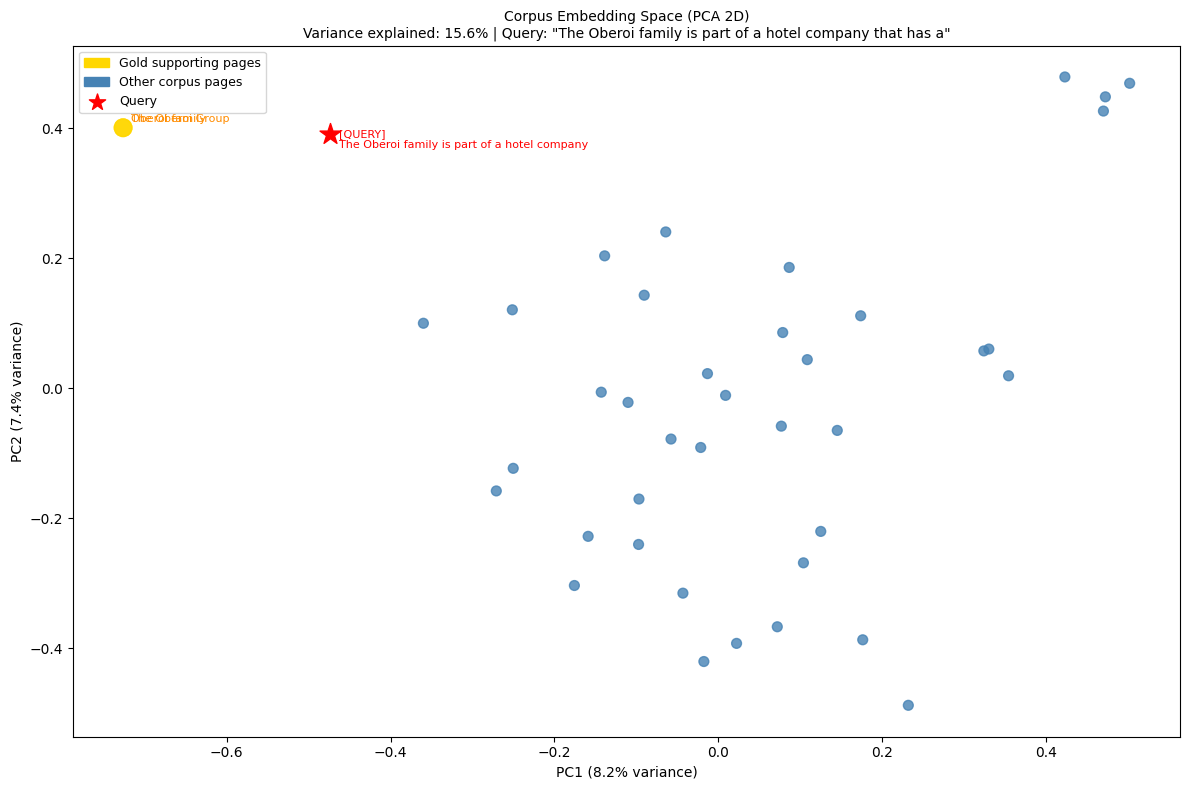

Pages nearest to the red star (query) will be retrieved first.
Gold pages (orange) should ideally cluster near the query.


In [12]:
q = questions[0]

# Embed corpus (truncated for speed — first 600 chars per page)
all_texts  = [p['text'][:600] for p in corpus]
all_titles = [p['title'] for p in corpus]
q_text     = q['question']

combined_texts = all_texts + [q_text]
combined_vecs  = embed_texts(combined_texts)

# Project to 2D
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined_vecs)

corpus_coords = coords[:-1]
query_coords  = coords[-1]

gold_set = set(q['supporting_titles'])

# Colors and sizes
point_colors = ['gold' if t in gold_set else 'steelblue' for t in all_titles]
point_sizes  = [160 if t in gold_set else 50 for t in all_titles]

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(corpus_coords[:, 0], corpus_coords[:, 1],
           c=point_colors, s=point_sizes, alpha=0.8, zorder=3)
ax.scatter(*query_coords, c='red', s=250, marker='*', zorder=5, label='Query')

# Label gold pages and query
for i, title in enumerate(all_titles):
    if title in gold_set:
        ax.annotate(title[:30], corpus_coords[i], fontsize=8,
                    xytext=(6, 4), textcoords='offset points', color='darkorange')
ax.annotate(f'[QUERY]\n{q["question"][:45]}', query_coords, fontsize=8,
            xytext=(6, -10), textcoords='offset points', color='red')

gold_p  = mpatches.Patch(color='gold',      label='Gold supporting pages')
blue_p  = mpatches.Patch(color='steelblue', label='Other corpus pages')
ax.legend(handles=[gold_p, blue_p, plt.scatter([], [], c='red', marker='*', s=150, label='Query')],
          fontsize=9)
ax.set_title(
    f'Corpus Embedding Space (PCA 2D)\n'
    f'Variance explained: {pca.explained_variance_ratio_.sum():.1%} | '
    f'Query: "{q["question"][:55]}"',
    fontsize=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'embedding_space_pca.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Pages nearest to the red star (query) will be retrieved first.')
print('Gold pages (orange) should ideally cluster near the query.')

---
## Part 7 — The Full Retrieval Pipeline: End-to-End Trace

Let's trace a single question through every step of Simple RAG:

```
Question string
    │
    ▼ embed_texts([question])     → (1, 384) query vector
    │
    ▼ index.search(q_vec, k=5)    → top-5 indices + scores
    │
    ▼ corpus[idx] for each idx    → list of page dicts with _score
    │
    ▼ concatenate page texts      → context string
    │
    ▼ compute_em / compute_f1     → retrieval quality metrics
```


In [13]:
q = questions[2]   # use question 2 for variety
print('=' * 65)
print('FULL PIPELINE TRACE')
print('=' * 65)
print()
print(f'INPUT  : "{q["question"]}"')
print(f'GOLD   : "{q["answer"]}"')
print(f'NEEDS  : {q["supporting_titles"]}')
print()

# ── Step A ────────────────────────────────────────────────────────────────────
print('━━━ Step A: Embed the query ━━━')
q_vec = embed_texts([q['question']])
print(f'  Input  : string with {len(q["question"])} characters')
print(f'  Output : float32 array of shape {q_vec.shape}')
print(f'  First 6 dims: {np.round(q_vec[0, :6], 4)}')
print(f'  L2 norm: {np.linalg.norm(q_vec[0]):.6f}  (exactly 1.0 after normalisation)')
print()

# ── Step B ────────────────────────────────────────────────────────────────────
print('━━━ Step B: FAISS inner product search ━━━')
raw_scores, raw_idxs = index.search(q_vec, k=5)
print(f'  Call   : index.search(q_vec, k=5)')
print(f'  Returns scores : {np.round(raw_scores[0], 4)}')
print(f'  Returns indices: {raw_idxs[0]}')
print(f'  These are cosine similarities (0=unrelated, 1=identical)')
print()

# ── Step C ────────────────────────────────────────────────────────────────────
print('━━━ Step C: Map indices to corpus pages ━━━')
pages = retrieve(q['question'], index, corpus, k=5)
for i, p in enumerate(pages):
    gold = '✓ GOLD' if p['title'] in q['supporting_titles'] else ''
    print(f'  [{i+1}] score={p["_score"]:.4f}  {p["title"][:45]}  {gold}')
print()

# ── Step D ────────────────────────────────────────────────────────────────────
print('━━━ Step D: Concatenate page texts into context ━━━')
context = '\n\n'.join(p['text'] for p in pages)
print(f'  Concatenated {len(pages)} pages')
print(f'  Context length: {len(context):,} chars  ({len(context.split()):,} words)')
print(f'  Preview: "{context[:120]}..."')
print()

# ── Step E ────────────────────────────────────────────────────────────────────
print('━━━ Step E: Compute retrieval metrics ━━━')
em  = compute_em(context, q['answer'])
f1  = compute_f1(context, q['answer'])
sr  = compute_supporting_recall([p['title'] for p in pages], q['supporting_titles'])
print(f'  EM (gold answer in context?)     : {em}')
print(f'  F1 (word overlap with answer)    : {f1:.4f}')
print(f'  Supporting Recall (gold pages %) : {sr:.2f}')

FULL PIPELINE TRACE

INPUT  : " What nationality was James Henry Miller's wife?"
GOLD   : "American"
NEEDS  : ['Peggy Seeger', 'Ewan MacColl']

━━━ Step A: Embed the query ━━━
  Input  : string with 48 characters
  Output : float32 array of shape (1, 384)
  First 6 dims: [-0.0035 -0.0782 -0.1259  0.0563 -0.0303  0.0216]
  L2 norm: 1.000000  (exactly 1.0 after normalisation)

━━━ Step B: FAISS inner product search ━━━
  Call   : index.search(q_vec, k=5)
  Returns scores : [0.3898 0.2286 0.212  0.19   0.1196]
  Returns indices: [10 37 38 31  2]
  These are cosine similarities (0=unrelated, 1=identical)

━━━ Step C: Map indices to corpus pages ━━━
  [1] score=0.3898  Ewan MacColl  ✓ GOLD
  [2] score=0.2286  Walter Coy  
  [3] score=0.2120  Warren Bryant  
  [4] score=0.1900  Peggy Seeger  ✓ GOLD
  [5] score=0.1196  Annette Bening  

━━━ Step D: Concatenate page texts into context ━━━
  Concatenated 5 pages
  Context length: 31,252 chars  (5,316 words)
  Preview: "British folk singer-songw

---
## Part 8 — HyperRAG: Bridging Multi-Hop Questions with Hyperlinks

For multi-hop questions, FAISS alone can fail. Consider:

> *"What is the nationality of the wife of Peggy Seeger's brother?"*

FAISS retrieves the *Peggy Seeger* page (most similar to the query).  
But the answer is on the *Ewan MacColl* page — Peggy's brother.  
The Peggy Seeger article **links to** Ewan MacColl — the hyperlink is the bridge.

### 1-hop expansion algorithm

```
1. FAISS retrieval → initial set S (top-k pages)
2. For each page p in S:
     follow all outgoing links:  p → neighbor  (pages p links to)
     follow all incoming links:  neighbor → p  (pages that link to p)
3. Collect new neighbors not already in S → candidate set C
4. Re-rank C by query similarity → take top expand_k pages
5. Final context = S + top expand_k candidates
```


In [14]:
# ── Build the hyperlink graph ──────────────────────────────────────────────────
corpus_titles = {p['title'] for p in corpus}
G = nx.DiGraph()
G.add_nodes_from(corpus_titles)
for page in corpus:
    for link in page['links']:
        if link in corpus_titles and link != page['title']:
            G.add_edge(page['title'], link)

print('Hyperlink Graph Statistics')
print('=' * 40)
print(f'  Nodes (corpus pages) : {G.number_of_nodes()}')
print(f'  Edges (hyperlinks)   : {G.number_of_edges()}')
print(f'  Density              : {nx.density(G):.4f}')
print()

# Show pages with links to other corpus pages
edges = [(u, v) for u, v in G.edges()]
if edges:
    print('Inter-page connections found:')
    for u, v in edges:
        print(f'  {u[:35]} → {v[:35]}')
else:
    print('No inter-page links in this small corpus.')
    print('(The corpus was built for 20 questions — graph edges require overlapping link sets.)')

Hyperlink Graph Statistics
  Nodes (corpus pages) : 40
  Edges (hyperlinks)   : 15
  Density              : 0.0096

Inter-page connections found:
  Hurt Locker (musical) → Metallica
  House of Anubis → Het Huis Anubis
  Indogrammodes → India
  Sue Donahue → Kelli Ward
  Gunmen from Laredo → Walter Coy
  The Great Outdoors (film) → Annette Bening
  Die Rhöner Säuwäntzt → Skiffle
  Het Huis Anubis → House of Anubis
  Joe Heck → Catherine Cortez Masto
  Fast Cars, Danger, Fire and Knives → El-P
  Global Fighting Championship → Badr Hari
  Badr Hari → Global Fighting Championship
  Peggy Seeger → Ewan MacColl
  Allie Goertz → Milhouse Van Houten
  Walter Coy → Gunmen from Laredo


In [15]:
# ── Trace graph expansion for a multi-hop question ────────────────────────────
# Use the question about Peggy Seeger / Ewan MacColl if available
multi_hop_q = next(
    (q for q in questions if 'Peggy' in q['question'] or 'Ewan' in q['question']),
    questions[2]
)
print(f'Tracing expansion for: "{multi_hop_q["question"]}"')
print(f'Gold answer : {multi_hop_q["answer"]}')
print(f'Gold pages  : {multi_hop_q["supporting_titles"]}')
print()

initial_pages  = retrieve(multi_hop_q['question'], index, corpus, k=5)
initial_titles = {p['title'] for p in initial_pages}
title_to_page  = {p['title']: p for p in corpus}

print('FAISS initial retrieval (k=5):')
for p in initial_pages:
    gold = '✓' if p['title'] in multi_hop_q['supporting_titles'] else ' '
    print(f'  {gold} {p["title"]:<45} score={p["_score"]:.3f}')

print()
print('1-hop graph expansion:')

neighbor_titles = set()
for page in initial_pages:
    if not G.has_node(page['title']):
        continue
    out_nbrs = [t for t in G.successors(page['title'])   if t in title_to_page and t not in initial_titles]
    in_nbrs  = [t for t in G.predecessors(page['title']) if t in title_to_page and t not in initial_titles]
    all_nbrs = out_nbrs + in_nbrs
    if all_nbrs:
        print(f'  "{page["title"]}" links to/from: {all_nbrs}')
        neighbor_titles.update(all_nbrs)

if not neighbor_titles:
    print('  (No graph edges found for this corpus — expansion adds 0 new pages)')
    print('  This is expected with a small 40-page corpus.')
    print()
    print('  With a larger corpus (N=200+), graph edges become common and expansion helps.')
else:
    print(f'\n  Total new candidate pages: {len(neighbor_titles)}')
    # Re-rank by query similarity
    cand_pages = [title_to_page[t] for t in neighbor_titles]
    cand_vecs  = embed_texts([p['text'] for p in cand_pages])
    q_vec_     = embed_texts([multi_hop_q['question']])
    scores_    = (q_vec_ @ cand_vecs.T)[0]
    top_idxs   = scores_.argsort()[::-1][:3]
    print('\n  After re-ranking — top-3 expanded pages:')
    for idx in top_idxs:
        gold = '✓' if cand_pages[idx]['title'] in multi_hop_q['supporting_titles'] else ' '
        print(f'    {gold} {cand_pages[idx]["title"]}  (score={scores_[idx]:.3f})')

Tracing expansion for: " What nationality was James Henry Miller's wife?"
Gold answer : American
Gold pages  : ['Peggy Seeger', 'Ewan MacColl']

FAISS initial retrieval (k=5):
  ✓ Ewan MacColl                                  score=0.390
    Walter Coy                                    score=0.229
    Warren Bryant                                 score=0.212
  ✓ Peggy Seeger                                  score=0.190
    Annette Bening                                score=0.120

1-hop graph expansion:
  "Walter Coy" links to/from: ['Gunmen from Laredo', 'Gunmen from Laredo']
  "Annette Bening" links to/from: ['The Great Outdoors (film)']

  Total new candidate pages: 2

  After re-ranking — top-3 expanded pages:
      The Great Outdoors (film)  (score=0.067)
      Gunmen from Laredo  (score=0.034)


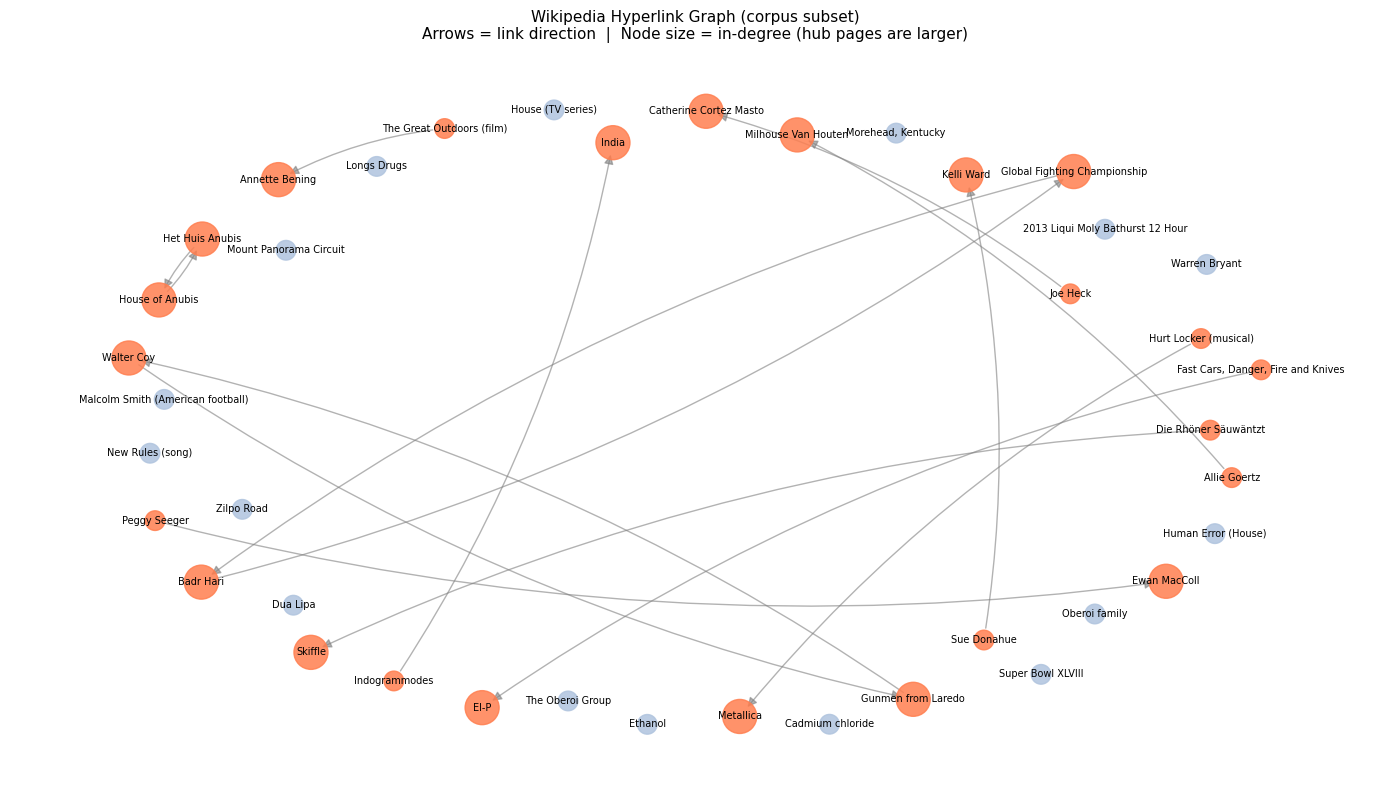

In [16]:
# ── Visualise the hyperlink graph ─────────────────────────────────────────────
if G.number_of_edges() > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    pos = nx.spring_layout(G, seed=42, k=3.0)

    in_deg     = dict(G.in_degree())
    node_sizes = [200 + in_deg[n] * 400 for n in G.nodes()]
    node_colors = ['coral' if in_deg[n] > 0 or G.out_degree(n) > 0 else 'lightsteelblue'
                   for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=14,
                           edge_color='gray', alpha=0.6,
                           connectionstyle='arc3,rad=0.1', ax=ax)
    ax.set_title('Wikipedia Hyperlink Graph (corpus subset)\n'
                 'Arrows = link direction  |  Node size = in-degree (hub pages are larger)',
                 fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(DATA_DIR / 'hyperlink_graph_explained.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('No inter-page edges in this corpus — skipping graph visualisation.')
    print()
    print('To see a richer graph: increase N to 100+ in notebook 01 and re-run.')

---
## Summary — Everything You Need to Know

### The complete retrieval pipeline

```
Wikipedia pages
  │
  ▼  [Chunking]   →  one chunk per page (page-level)  →  list of text strings
  │
  ▼  [Embedding]  →  embed_texts()  →  (N, 384) float32 matrix, L2-normalised
  │
  ▼  [Indexing]   →  faiss.IndexFlatIP(384).add(embeddings)
  │
                              User Question
                                 │
                                 ▼  embed_texts([question])  →  (1, 384) query vector
                                 │
                                 ▼  index.search(q_vec, k=5)  →  scores + indices
                                 │
                                 ▼  map indices → corpus pages  →  retrieved page list
                                 │
                              [Simple RAG]  →  plain text context
                              [HtmlRAG]     →  cleaned HTML context
                              [HyperRAG]    →  plain text + graph-expanded pages
                                 │
                                 ▼  compute_em / compute_f1 / compute_supporting_recall
```

### Key concepts at a glance

| Concept | What it does | Key number |
|---------|-------------|------------|
| Chunk | Unit of text indexed as one vector | 1 page |
| Embedding | 384-dim vector representing meaning | 384 floats |
| L2 normalise | Force all vectors to unit length | `faiss.normalize_L2()` |
| IndexFlatIP | Exact inner product search | O(n × 384) per query |
| k | Number of top pages retrieved | 5 (default) |
| Graph expansion | Follow hyperlinks 1-hop | expand_k=3 (default) |
| EM | Is gold answer substring of context? | 0 or 1 |
| F1 | Word-level overlap between context and gold | 0.0 – 1.0 |
| Supporting Recall | Fraction of gold pages retrieved | 0.0 – 1.0 |

### Why HyperRAG helps (in theory)

Multi-hop questions require two pages (A → B). FAISS finds A (semantically similar to the query)
but B may be semantically distant from the question — it's only *referenced* by A.
The hyperlink graph makes this structural connection explicit: if A links to B, HyperRAG retrieves B too.

> **With a small 40-page corpus and a sparse graph, this benefit is limited.**  
> Increase `N` to 200+ in notebook 01 to see the graph become denser and HyperRAG's
> advantage more visible.
